<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/UberCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import requests
import io
from imblearn.over_sampling import SMOTE

In [2]:
!gdown --fuzzy --output uber_dataset.csv https://drive.google.com/file/d/13KW_CuVVqU3e2coQkUwhD_F-w4A_gcoo/view

Downloading...
From: https://drive.google.com/uc?id=13KW_CuVVqU3e2coQkUwhD_F-w4A_gcoo
To: /content/uber_dataset.csv
100% 25.5M/25.5M [00:00<00:00, 136MB/s]


In [3]:
data = pd.read_csv('/content/uber_dataset.csv')

In [4]:
#cleaning column names
def column_name_cleaning(df):
  df.columns=df.columns.str.strip()
  df.columns=df.columns.str.lower()
  df.columns=df.columns.str.replace(' ','_')
  return df
data=column_name_cleaning(data)

In [5]:
data

,date,time,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [6]:
data.describe()

,avg_vtat,avg_ctat,cancelled_rides_by_customer,cancelled_rides_by_driver,incomplete_rides,booking_value,ride_distance,driver_ratings,customer_rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   date                               150000 non-null  object 
 1   time                               150000 non-null  object 
 2   booking_id                         150000 non-null  object 
 3   booking_status                     150000 non-null  object 
 4   customer_id                        150000 non-null  object 
 5   vehicle_type                       150000 non-null  object 
 6   pickup_location                    150000 non-null  object 
 7   drop_location                      150000 non-null  object 
 8   avg_vtat                           139500 non-null  float64
 9   avg_ctat                           102000 non-null  float64
 10  cancelled_rides_by_customer        10500 non-null   float64
 11  reason_for_cancelling_by_customer  1050

In [8]:
# checking for missing values
# data.isna().sum()
100*data.notna().sum()/len(data)
# 100*data.isna().sum()/len(data)

,0
date,100.0
time,100.0
booking_id,100.0
booking_status,100.0
customer_id,100.0
vehicle_type,100.0
pickup_location,100.0
drop_location,100.0
avg_vtat,93.0
avg_ctat,68.0


#### From preliminary data observation, we can understand that:
#### 7% rides are cancelled by customers
#### 18% rides are cancelled by drivers
#### 6% are incomplete rides with reasons ['Vehicle Breakdown', 'Other Issue', 'Customer Demand']

In [9]:
data[data['ride_distance'].isna()]['booking_status'].unique()
data[data['booking_status']=='Completed']['ride_distance'].isna().unique()

array([False])

In [10]:
data[data['booking_value'].isna()]['booking_status'].unique()
data[data['booking_status']=='Completed']['booking_value'].isna().unique()

array([False])

In [11]:
data[data['payment_method'].isna()]['booking_status'].unique()
data[data['booking_status']=='Completed']['payment_method'].isna().unique()

array([False])

In [12]:
data[data['driver_ratings'].isna()]['booking_status'].unique()
data[data['booking_status']=='Completed']['driver_ratings'].isna().unique()

array([False])

In [13]:
data[data['customer_rating'].isna()]['booking_status'].unique()
# data[data['booking_status']=='Completed']['customer_rating'].isna().unique()

array(['No Driver Found', 'Incomplete', 'Cancelled by Driver',
       'Cancelled by Customer'], dtype=object)

In [14]:
data[data['booking_status']=='No Driver Found']['avg_vtat'].unique()

array([nan])

In [15]:
data[data['booking_status']=='Incomplete']['avg_vtat'].isna().unique()

array([False])

In [16]:
data[data['booking_status']=='Cancelled by Driver']['avg_vtat'].isna().unique()

array([False])

In [17]:
data[data['booking_status']=='Cancelled by Customer']['avg_vtat'].isna().unique()

array([False])

In [18]:
data[data['avg_ctat'].isna()]['booking_status'].unique()
data[data['booking_status']=='Completed']['avg_ctat'].isna().unique()

array([False])

In [19]:
data[data['booking_status']=='No Driver Found']['avg_ctat'].isna().unique()

array([ True])

In [20]:
data[data['booking_status']=='Cancelled by Driver']['avg_ctat'].isna().unique()

array([ True])

In [21]:
data[data['booking_status']=='Cancelled by Customer']['avg_ctat'].isna().unique()

array([ True])

#### 32% data in columns: ['ride_distance', 'booking_value', 'payment_method'] is null. These are rows that have 'booking_status' other than "Completed".
#### 38% data in columns: ['driver_ratings', 'customer_rating'] is null. These are rows with 'booking_status' other than "Completed".
#### avg_vtat has 7% nulls, all for rows with 'booking_status'='No Driver Found', and for other 'booking_status' it is not null. This tells us that there is no discrapency in vtat data.
### avg_ctat has 32% nulls, all for rows with 'booking_status'="Completed", and for others it is not null. Indicating no discrapency in avg_ctat values.
#### No discrepancy in 'ride_distance' column, it is not null for rows with booking status "Completed" and null for others.
#### Similarly, for 'booking_value', 'payment_method', 'driver_ratings', 'customer_rating' columns.

In [22]:
# Customer cancellation rate creation
data['is_customer_cancel']=data['booking_status'].apply(lambda x: 1 if x=='Cancelled by Customer' else 0)
customer_cancel_group=data.groupby('customer_id').agg(cancel_count=('is_customer_cancel','sum'))

customer_book_group=data.groupby('customer_id').agg(book_count=('booking_id','count'))

data['cancel_count']=data['customer_id'].map(customer_cancel_group['cancel_count'])
data['book_count']=data['customer_id'].map(customer_book_group['book_count'])
data['customer_cancel_rate']=(100*data['cancel_count']/data['book_count']).round(2)
# data['customer_cancel_rate'].unique()

data.drop(columns=['is_customer_cancel','cancel_count','book_count'], axis=1, inplace=True)

In [23]:
# Binarizing booking status
data['booking_status_bin']=data['booking_status'].apply(lambda x: 1 if x=='Completed' else 0)

In [24]:
potential_leakgae_cols=['driver_ratings', 'customer_rating', 'booking_value', 'payment_method', 'ride_distance']  # these are only available once ride proceeeds or completes. So, for ['No Driver Found', 'Incomplete', 'Cancelled by Driver','Cancelled by Customer'] booking_status' these are potential leakage cols.

#### Doubt: Should we delete these leakgae columsn or not?

# Data Handling

In [25]:
data.head()

,date,time,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,...,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,customer_cancel_rate,booking_status_bin
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,0.0,0
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,0.0,1
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,0.0,1
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,0.0,1


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   date                               150000 non-null  object 
 1   time                               150000 non-null  object 
 2   booking_id                         150000 non-null  object 
 3   booking_status                     150000 non-null  object 
 4   customer_id                        150000 non-null  object 
 5   vehicle_type                       150000 non-null  object 
 6   pickup_location                    150000 non-null  object 
 7   drop_location                      150000 non-null  object 
 8   avg_vtat                           139500 non-null  float64
 9   avg_ctat                           102000 non-null  float64
 10  cancelled_rides_by_customer        10500 non-null   float64
 11  reason_for_cancelling_by_customer  1050

In [27]:
data['date']=pd.to_datetime(data['date'])

In [28]:
data['time_hour']=pd.to_datetime(data['time']).dt.hour

/tmp/ipython-input-1265285900.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['time_hour']=pd.to_datetime(data['time']).dt.hour


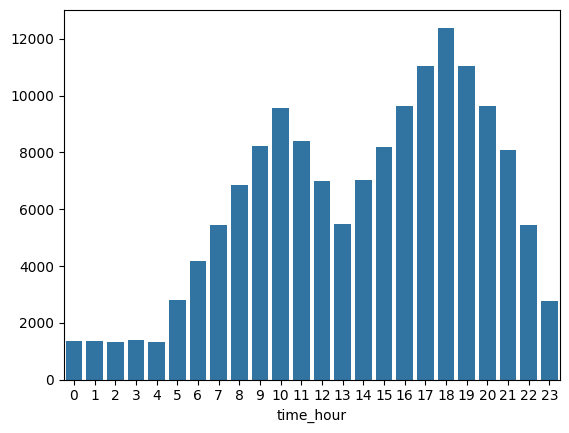

In [29]:
hour_demand=data.groupby('time_hour').size()
sns.barplot(x=hour_demand.index, y=hour_demand.values)
plt.show()

In [30]:
time_labels=['Late Night','Morning Peak', 'Midday', 'Evening Rush','Night']
hour_bins=[0,5,11,15,18,23]
data['time_slot_of_day']=pd.cut(data['time_hour'],bins=hour_bins, labels=time_labels, right=True, include_lowest=True)

In [31]:
# pickup location density score creation
# data['pickup_location'].nunique()#176 pickup locations
# pd.Series(data['pickup_location'].unique()).sort_values()
pickup_demand=data.groupby('pickup_location').agg(demand=('booking_id','count'), completed=('booking_status_bin','sum'))
pickup_demand['completion_rate']=100*pickup_demand['completed']/pickup_demand['demand']
pickup_demand.sort_values(by='completion_rate',ascending=False)
#capturing only driver demand and completion rate, not focussing on driver pressures
# completion rate is not a great signal for defining location density
pickup_demand['pickup_location_density_score']=np.log1p(pickup_demand['demand'])*pickup_demand['completion_rate']
pickup_demand.sort_values(by='pickup_location_density_score',ascending=False)
#ensures high demand and high completion rate to score better
data['pickup_location_density_score']=data['pickup_location'].map(pickup_demand['pickup_location_density_score'])
data['pickup_location_density_score']

,pickup_location_density_score
0,429.711010
1,426.467361
2,433.496016
3,418.129009
4,418.981746
...,...
149995,412.451664
149996,416.590063
149997,414.421293
149998,413.894262


In [32]:
# drop location density score creation
# data['drop_location'].nunique()#176 pickup locations
# pd.Series(data['drop_location'].unique()).sort_values()
drop_demand=data.groupby('drop_location').agg(demand=('booking_id','count'), completed=('booking_status_bin','sum'))
drop_demand['completion_rate']=100*drop_demand['completed']/drop_demand['demand']
drop_demand.sort_values(by='completion_rate',ascending=False)

#capturing only driver demand and completion rate, not focussing on driver pressures
# completion rate is not a great signal for defining location density
drop_demand['drop_location_density_score']=np.log1p(drop_demand['demand'])*drop_demand['completion_rate']
drop_demand.sort_values(by='drop_location_density_score',ascending=False)

# #ensures high demand and high completion rate to score better
data['drop_location_density_score']=data['drop_location'].map(drop_demand['drop_location_density_score'])
data['drop_location_density_score']

,drop_location_density_score
0,425.669442
1,415.108026
2,424.041694
3,420.640016
4,430.170968
...,...
149995,412.686805
149996,436.291024
149997,435.309489
149998,420.010790


### pickup and drop locations are encoded using historical density scores that combine booking volume and completion rate per zone. This approach captures both geographical activity density and behaviorial similarity, serving same purpose as target encoding.

In [33]:
data['time_slot_of_day'].unique()

['Midday', 'Evening Rush', 'Morning Peak', 'Night', 'Late Night']
Categories (5, object): ['Late Night' < 'Morning Peak' < 'Midday' < 'Evening Rush' < 'Night']

In [34]:
# trip duration feature definition: defined with estimations on vehicle speed and speed multiplier according to time
# data['ride_distance'].unique()
vehicle_base_speed = {
    'eBike': 35,
    'Bike': 32,
    'Go Mini': 28,
    'Go Sedan': 27,
    'Premier Sedan': 27,
    'Auto': 22,
    'Uber XL': 24
}
time_speed_multiplier = {
    'Late Night': 1.3,
    'Morning Peak': 0.6,
    'Midday': 1.0,
    'Evening Rush': 0.6,
    'Night': 1.2
}
data['base_speed'] = data['vehicle_type'].map(vehicle_base_speed)
data['traffic_multiplier'] = data['time_slot_of_day'].map(time_speed_multiplier)

data['expected_speed'] = (
    data['base_speed'] * data['traffic_multiplier']
)
data['trip_duration'] = 60*data['ride_distance'] / data['expected_speed']
data.drop(columns=['base_speed', 'traffic_multiplier', 'expected_speed'], axis=1, inplace=True)
data['trip_duration']

,trip_duration
0,NaN
1,21.222222
2,61.727273
3,126.000000
4,75.328125
...,...
149995,71.571429
149996,45.664286
149997,59.000000
149998,207.000000


In [35]:
#day type feature
data['day_type']=(data['date'].dt.day_of_week).apply(lambda x: 'Weekday' if x<5 else 'Weekend')

# Data Cleaning

In [36]:
potential_leakgae_cols

['driver_ratings',
 'customer_rating',
 'booking_value',
 'payment_method',
 'ride_distance']

In [37]:
# binarize booking_value column
data['is_booking_value_available']=data['booking_value'].apply(lambda x: 1 if pd.notnull(x) else 0)
data['booking_value']=data['booking_value'].apply(lambda x: -1 if pd.isnull(x) else x) # -1 means missing value
data[data['booking_value']==-1][['booking_value','is_booking_value_available']]

,booking_value,is_booking_value_available
0,-1.0,0
8,-1.0,0
11,-1.0,0
12,-1.0,0
17,-1.0,0
...,...,...
149979,-1.0,0
149980,-1.0,0
149982,-1.0,0
149990,-1.0,0


In [38]:
#binarize ride distance column
data['is_ride_distance_available']=data['ride_distance'].apply(lambda x: 1 if pd.notnull(x) else 0)
data['ride_distance']=data['ride_distance'].apply(lambda x: -1 if pd.isnull(x) else x) # -1 means missing value
data[data['ride_distance']==-1][['ride_distance','is_ride_distance_available']]

,ride_distance,is_ride_distance_available
0,-1.0,0
8,-1.0,0
11,-1.0,0
12,-1.0,0
17,-1.0,0
...,...,...
149979,-1.0,0
149980,-1.0,0
149982,-1.0,0
149990,-1.0,0


In [39]:
# imputing avg_vtat with mean
data['avg_vtat']=data.groupby('vehicle_type')['avg_vtat'].transform(lambda x: x.fillna(x.median()))

In [40]:
data['avg_ctat']=data.groupby('vehicle_type')['avg_ctat'].transform(lambda x: x.fillna(x.median()))

In [41]:
# data[['time','date']]
data['date_time_combined']=pd.to_datetime(data['date'].astype(str)+' '+data['time'].astype(str))
data.drop(columns=['date','time'], axis=1, inplace=True, errors='ignore')

In [42]:
# potential_leakgae_cols
data.drop(columns=['driver_ratings', 'customer_rating'], axis=1, inplace=True)
potential_leakgae_cols.remove('driver_ratings')
potential_leakgae_cols.remove('customer_rating')

# Class balance Check

In [43]:
# function to split columns as cat and numerical columns
def find_cat_num_cols(df):
  # cat_cols=list(df.select_dtypes(include="object").columns)
  # num_cols=list(df.select_dtypes(exclude="object").columns)
  cat_cols=[]
  num_cols=[]
  for x in df.columns:
    if df[x].nunique()<10:
      cat_cols.append(x)
    else:
      num_cols.append(x)
  return cat_cols, num_cols

In [44]:
potential_leakgae_cols

['booking_value', 'payment_method', 'ride_distance']

In [45]:
# selecting only required columns
req_cols=['booking_status', 'booking_status_bin', 'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat','avg_ctat', 'time_hour', 'time_slot_of_day', 'day_type','pickup_location_density_score', 'drop_location_density_score']
# removing leakage columns: 'cancelled_rides_by_customer', 'cancelled_rides_by_driver', 'incomplete_rides', 'booking_value', 'ride_distance', 'payment_method', 'reason_for_cancelling_by_customer', 'incomplete_rides_reason', 'driver_cancellation_reason', 'customer_cancel_rate', 'is_booking_value_available', 'is_ride_distance_available', 'trip_duration'

In [46]:
dataset=data[req_cols].copy()
dataset.columns

Index(['booking_status', 'booking_status_bin', 'vehicle_type',
       'pickup_location', 'drop_location', 'avg_vtat', 'avg_ctat', 'time_hour',
       'time_slot_of_day', 'day_type', 'pickup_location_density_score',
       'drop_location_density_score'],
      dtype='object')

In [47]:
cat_cols, num_cols =find_cat_num_cols(dataset)

In [48]:
num_cols.remove('pickup_location')
num_cols.remove('drop_location')

# Remove NaN from cols before finding imbalances

In [49]:
cat_cols

['booking_status',
 'booking_status_bin',
 'vehicle_type',
 'time_slot_of_day',
 'day_type']

In [50]:
# #replacing nulls in 'cancelled_rides_by_customer','cancelled_rides_by_driver','incomplete_rides' with 0
# dataset['cancelled_rides_by_customer']=dataset['cancelled_rides_by_customer'].fillna(0)
# dataset['cancelled_rides_by_driver']=dataset['cancelled_rides_by_driver'].fillna(0)
# dataset['incomplete_rides']=dataset['incomplete_rides'].fillna(0)

In [51]:
# replacing nulls in trip_duration with 0
# dataset['trip_duration']=dataset['trip_duration'].fillna(0)

In [52]:
dataset.isna().sum()

,0
booking_status,0
booking_status_bin,0
vehicle_type,0
pickup_location,0
drop_location,0
avg_vtat,0
avg_ctat,0
time_hour,0
time_slot_of_day,0
day_type,0


In [53]:
# dataset[dataset['payment_method'].isna()]['booking_status'].unique()
# dataset[dataset['payment_method'].isna() & dataset['booking_status']=='Cancelled by Driver']
# dataset[dataset['booking_status']=='Incomplete'][['payment_method','booking_value']]

# Though booking_status is 'Incomplete', there are no null in 'ride_distance', 'booking_value', and 'payment_method'

In [54]:
dataset.drop(columns=['booking_status'], axis=1, inplace=True, errors='ignore')

In [55]:
#converting cat columns to numerical
def cat_to_num_convert(df, col_name, mapping_tuple, null_replacer_value):
  df[col_name]=df[col_name].replace(mapping_tuple).fillna(null_replacer_value).astype(int)
  return df

In [56]:
def vis_cat_cols(df, cat_cols,fig_size=(15,15), plot_col_num=3):
  plot_num_cols = plot_col_num
  plot_num_rows = len(cat_cols)//plot_num_cols+(1 if len(cat_cols)%plot_num_cols>0 else 0)
  fig, axes = plt.subplots(plot_num_rows, plot_num_cols, figsize=fig_size)
  axes = axes.flatten()

  for i, column in enumerate(cat_cols):
    sns.countplot(data=df,x=column,ax=axes[i])
    axes[i].set_title(f'Count Plot of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x',rotation=90)
  for j in range(i + 1, len(axes)): # Turn off any unused subplots
    fig.delaxes(axes[j])
  plt.tight_layout()
  plt.show()
  return

In [57]:
cat_cols, num_cols =find_cat_num_cols(dataset)

In [58]:
cat_cols

['booking_status_bin', 'vehicle_type', 'time_slot_of_day', 'day_type']

In [59]:
cat_cols=['booking_status_bin','vehicle_type','time_slot_of_day','day_type']

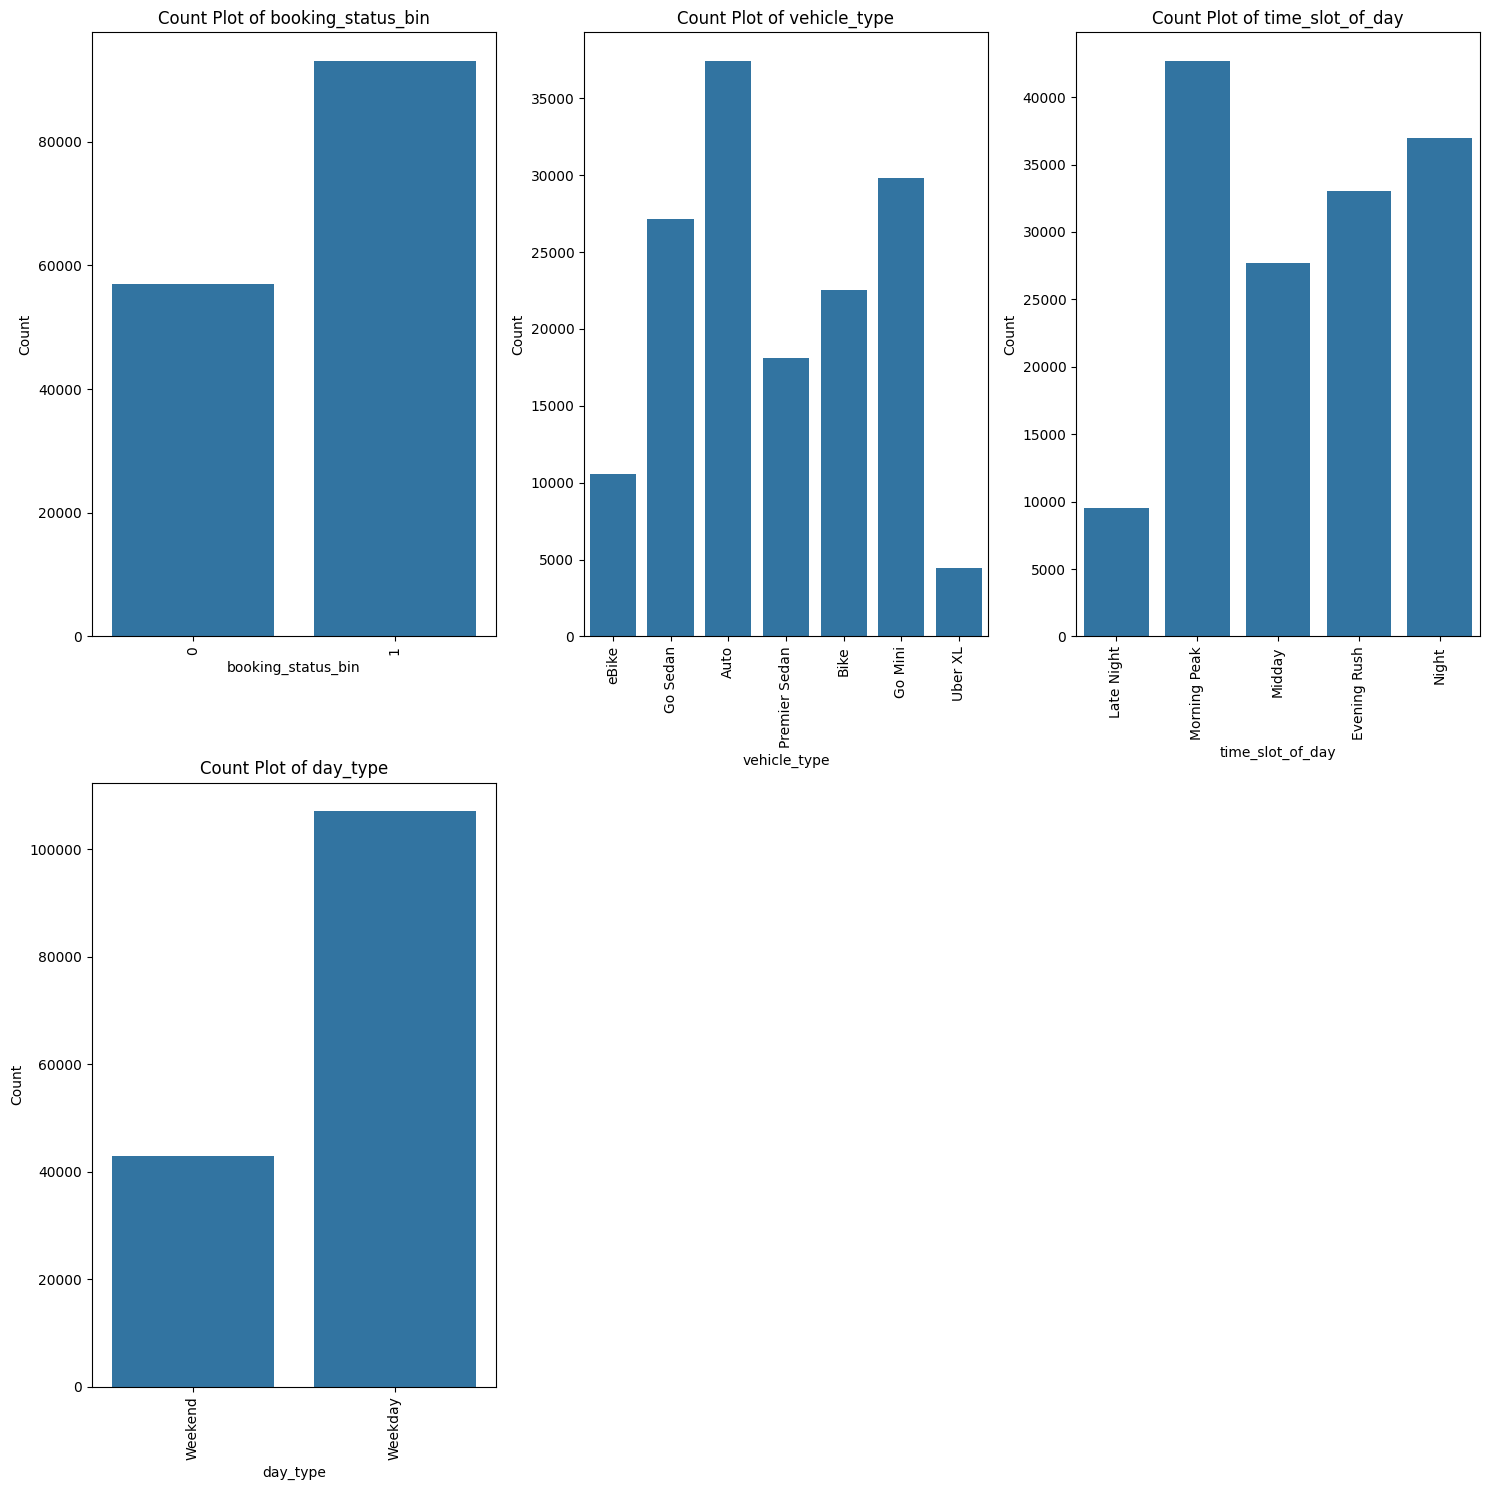

In [60]:
vis_cat_cols(dataset,cat_cols)

In [61]:
def vis_num_cols(df, num_cols, bins=20,fig_size=(15,15)):
  plot_num_cols = 2
  plot_num_rows = len(num_cols)//plot_num_cols+(1 if len(num_cols)%plot_num_cols>0 else 0)
  fig, axes = plt.subplots(plot_num_rows, plot_num_cols, figsize=fig_size)
  axes = axes.flatten()

  for i, column in enumerate(num_cols):
    sns.histplot(data=df, x=column, bins=bins,kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x',rotation=90)

  for j in range(i + 1, len(axes)): # Turn off any unused subplots
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()
  return

In [62]:
try:
  num_cols.remove('pickup_location')
  num_cols.remove('drop_location')
except:
  pass

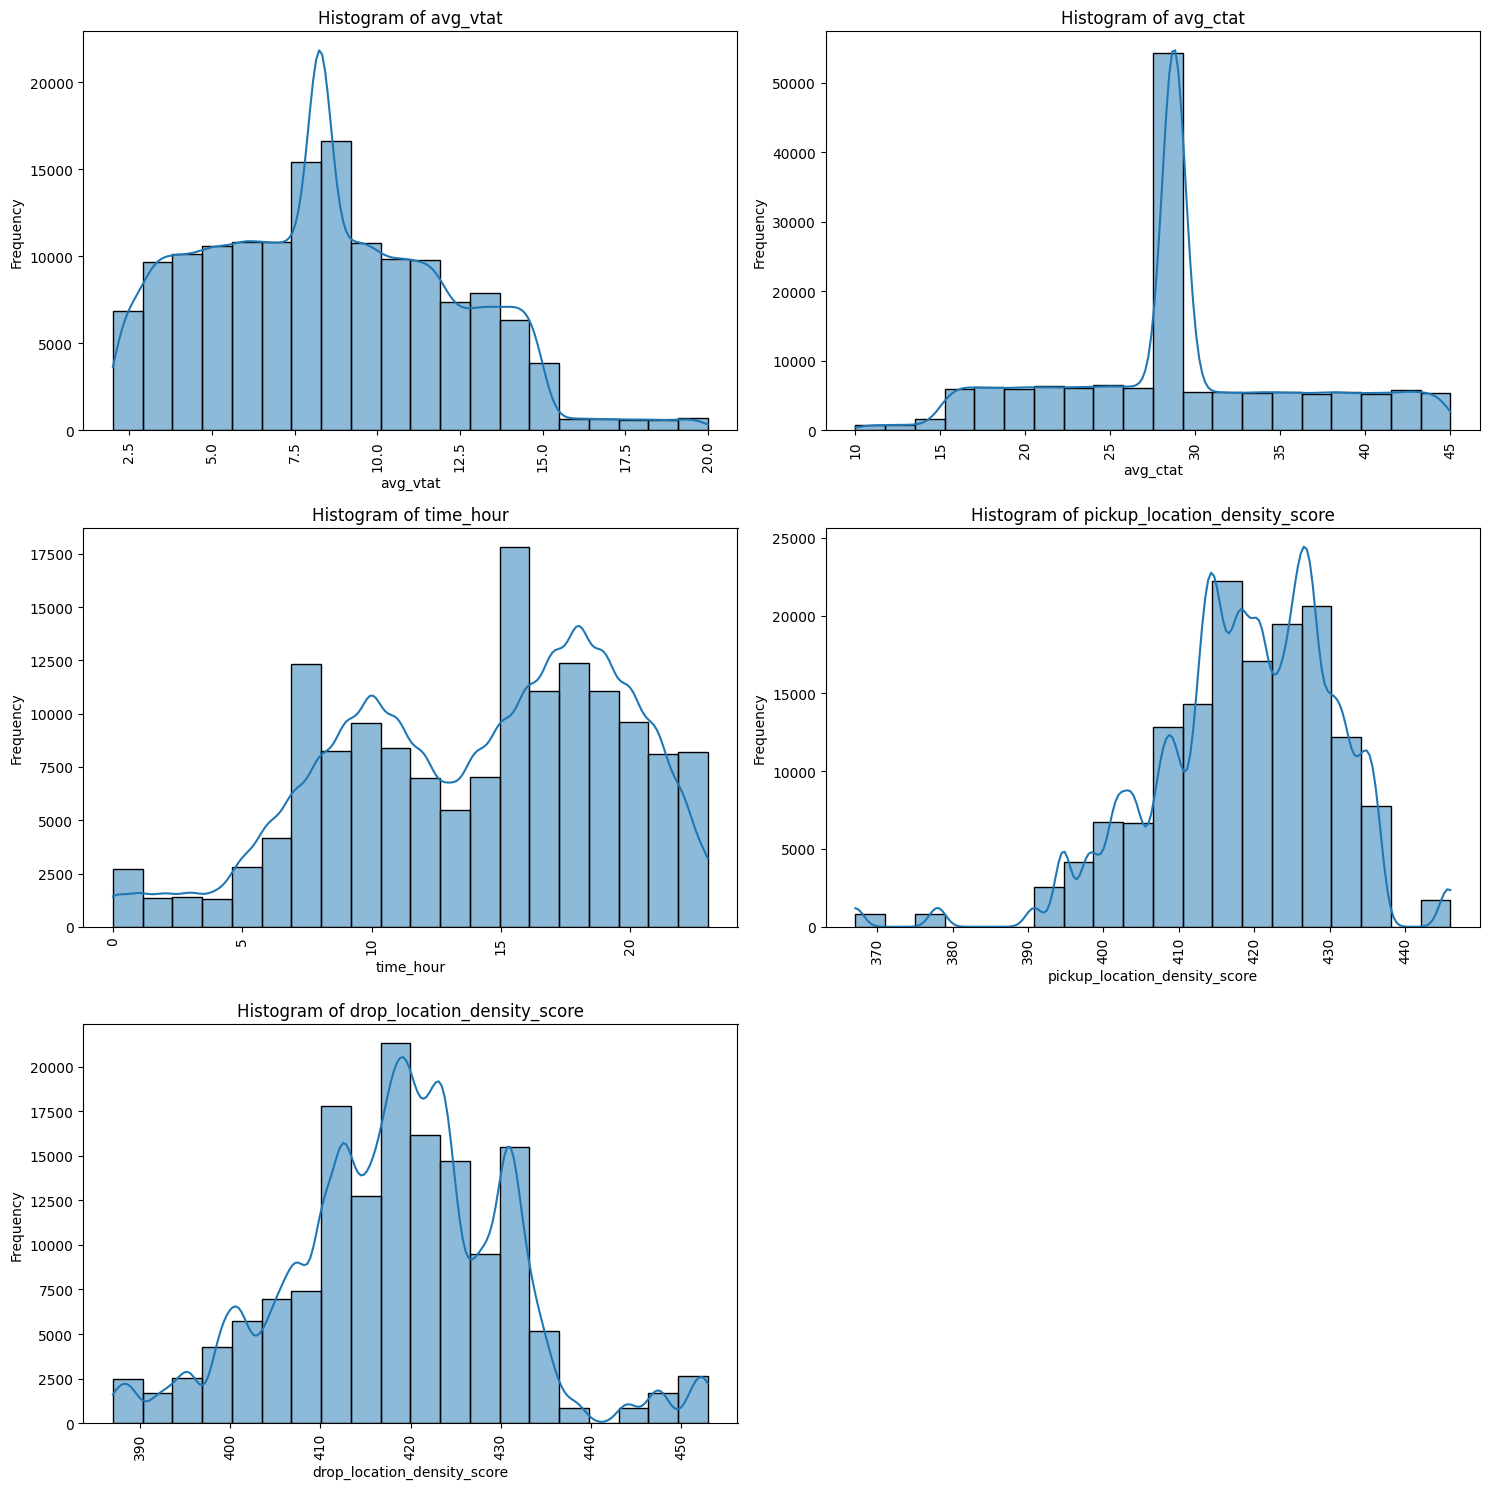

In [63]:
vis_num_cols(dataset,num_cols)

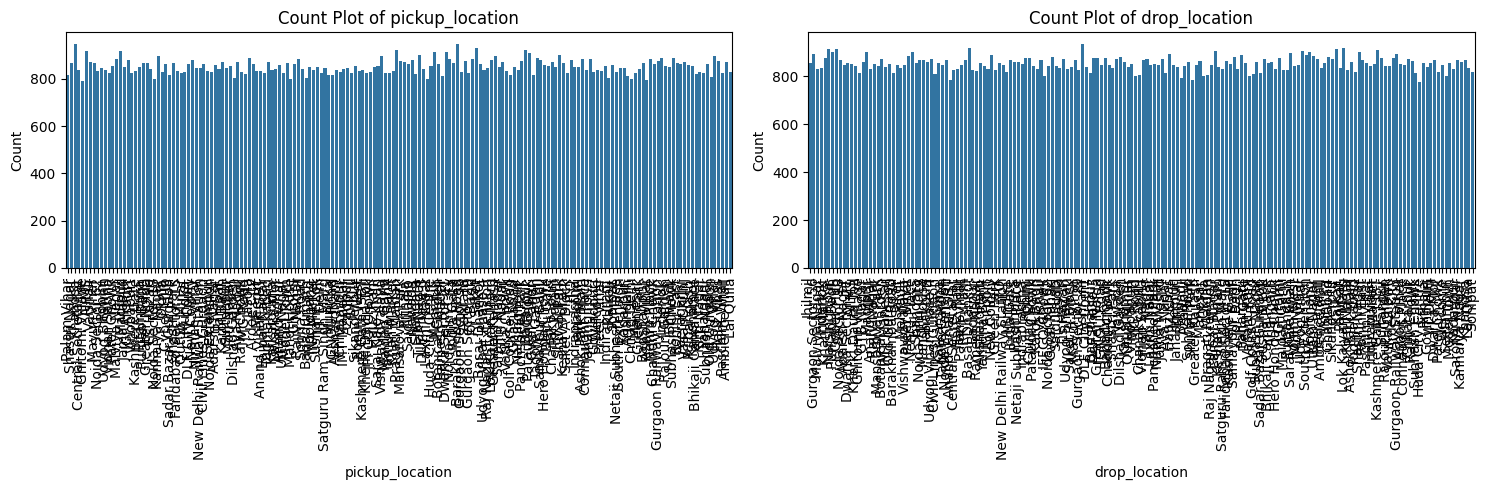

In [64]:
vis_cat_cols(dataset,['pickup_location','drop_location'],fig_size=(15,5),plot_col_num=2)

### pickup and drop location data is roughly balanced

In [65]:
dataset['booking_status_bin'].value_counts()*100/len(dataset)

,count
booking_status_bin,
1,62.0
0,38.0


### The target class is midly imbalanced, and doesn't require SMOTE automatically. I'll find recall, precision, f1_score, roc_auc and then decide on SMOTE based on underperformance on minority class.

### Q1. **Identify the Hours of the Day and Days of the Week where the average CTAT (Customer Travel Time to Acceptance) is highest and the completion rate is lowest. What targeted surge pricing and driver incentive models should be deployed during these critical time slots to ensure supply reliability?**

In [66]:
dataset['is_weekend']=dataset['day_type'].apply(lambda x: 1 if x=='Weekend' else 0)

In [67]:
summary_week_hour=dataset.groupby(['is_weekend','time_hour']).agg(mean_avg_ctat=('avg_ctat','mean'),mean_completion_rate=('booking_status_bin','mean'),demand=('time_hour','size'))
summary_week_hour.head()

mean_avg_ctat  mean_completion_rate  demand
is_weekend time_hour                                             
0          0              28.950409              0.619632     978
           1              28.839297              0.617373     967
           2              28.861546              0.637843     983
           3              29.105662              0.623862     989
           4              29.195469              0.637540     927

In [68]:
ctat_threshold = summary_week_hour['mean_avg_ctat'].quantile(0.75)
completion_threshold = summary_week_hour['mean_completion_rate'].quantile(0.25)

In [69]:
summary_week_hour['is_critical'] = (
    (summary_week_hour['mean_avg_ctat'] >= ctat_threshold) &
    (summary_week_hour['mean_completion_rate'] <= completion_threshold)
)

In [70]:
summary_week_hour[summary_week_hour['is_critical']==True]

mean_avg_ctat  mean_completion_rate  demand  is_critical
is_weekend time_hour                                                          
0          18             29.124183              0.610678    8841         True
1          6              29.178085              0.615186    1159         True
           14             29.163480              0.591424    2029         True

### **Ans.** *Analysis shows that weekend Morning Rush (6 AM), Midday (2 PM) and weekday Evening Rush (6 PM) exhibit the highest average CTAT alongside the lowest completion rates, indicating severe supply–demand mismatch during these windows*
### **Reasons for low completion in**
### 1. *Weekend Morning Rush : Late driver login, low perceived earnings vs effort*
### 2. *Weekend Midday : Driver break, drop location away from home, driver personal holiday*
### 3. *Weekday Evening Rush : Traffic and Driver selectivity--prefer short trips*
### **Targeted Interventions:**
### 1. *Early login bonuses, Guaranteed minimum earnings for morning slots, time bound surge multipliers(6-8 AM)*
### 2. *Food coupons incentives, zone-specific incentives, weekend surge for midday slots*
### 3. *Long trip duration bonuses, congestion-adjusted incentives*

In [71]:
dataset.drop(columns=['is_weekend'], axis=1, inplace=True)

Q1 Only partial answer

### Q2. **Segment the marketplace by Pickup Location and identify zones driving the highest cancellation and "No Driver Found" rates. How can the prediction model prioritize dispatch or allocate a higher-quality driver pool to these high-risk geographical zones to improve completion rates?**

In [72]:
data['is_completed']=(data['booking_status']=='Completed').astype(int)
data['is_no_driver_found']=(data['booking_status']=='No Driver Found').astype(int)
data['is_cancelled']=(data['booking_status'].isin(['Cancelled by Customer','Cancelled by Driver'])).astype(int)

In [73]:
pickup_summary = data.groupby('pickup_location').agg(
    total_requests=('booking_id', 'count'),
    completion_rate=('is_completed', 'mean'),
    no_driver_rate=('is_no_driver_found', 'mean'),
    cancelled_rate=('is_cancelled', 'mean'),
    mean_avg_ctat=('avg_ctat', 'mean')
).reset_index().round(2)

In [74]:
pickup_summary.sort_values(by='completion_rate', ascending=False)

,pickup_location,total_requests,completion_rate,no_driver_rate,cancelled_rate,mean_avg_ctat
174,Welcome,836,0.66,0.05,0.24,29.08
156,Subhash Chowk,887,0.66,0.07,0.21,28.77
129,RK Puram,850,0.65,0.06,0.23,29.21
57,IMT Manesar,840,0.65,0.06,0.23,28.85
159,Sushant Lok,850,0.65,0.07,0.23,29.40
...,...,...,...,...,...,...
14,Badshahpur,868,0.58,0.08,0.27,29.09
124,Pragati Maidan,920,0.58,0.08,0.27,29.56
24,Chhatarpur,829,0.58,0.08,0.28,28.76
2,Akshardham,839,0.56,0.07,0.30,28.74


In [75]:
request_threshold=pickup_summary['total_requests'].quantile(0.9)
no_driver_rate_threshold=pickup_summary['no_driver_rate'].quantile(0.8)
cancellation_rate_threshold=pickup_summary['cancelled_rate'].quantile(0.8)

In [76]:
high_risk_zone=pickup_summary[(pickup_summary['total_requests']>=request_threshold) & ((pickup_summary['no_driver_rate']>=no_driver_rate_threshold) | (pickup_summary['cancelled_rate']>=cancellation_rate_threshold))]

In [77]:
high_risk_zone

,pickup_location,total_requests,completion_rate,no_driver_rate,cancelled_rate,mean_avg_ctat
0,AIIMS,918,0.61,0.07,0.26,29.16
42,Greater Kailash,895,0.62,0.07,0.26,29.29
96,Mehrauli,915,0.63,0.08,0.24,28.96
120,Pataudi Chowk,907,0.61,0.09,0.24,29.01
124,Pragati Maidan,920,0.58,0.08,0.27,29.56
141,Saket,931,0.60,0.07,0.27,28.89
151,Shivaji Park,900,0.62,0.05,0.27,29.02
165,Udyog Vihar,897,0.60,0.07,0.26,28.73
173,Vishwavidyalaya,895,0.62,0.05,0.26,28.89


### **Ans.** *The descriptive analysis using segregarion of pickup locations and aggregating on completion rate, cancellation rate and no driver found rates. Focusing on high-volume zones with structurally high failure rates, these 9 pickup locations are in high-risk zones.*
### *These zones must be mapped with high-reliability drivers, shorter acceptance windows and expanded incentives. A predictive modelling can be used downstream to operationalize this insight by prioritizing dispatch, expanding search-radius(without increasing acceptance window) and driver allocation in real time.*

### **Q4. Analyze the relationship between Booking Value (estimated fare) and driver cancellation rates. Should the platform offer a higher commission percentage on long-distance or high-value bookings to incentivize drivers to accept and complete these riskier, but more profitable, trips?**

In [78]:
data[data['booking_status']=='Cancelled by Driver']['booking_value'].unique()

array([-1.])

### **Ans.** *In the dataset, booking value is not available to the driver-cancelled rides, which suggests drivers cancelled rides even before fare finalization. Therefore, we cannot establish direct relationship between booking_vlaue and driver cancellation from this data. This implies that increasing incentives would not prevent from driver cancellations. Instead, incentives should be designed around signals available at booking time-- pickup zone, estimated ctat, estimated vtat, or time of the day-- and post-acceptance bonuses can be used to encourage completion of longer or higher-valued trips.*

### **Q5. Analyze the most frequent Driver Cancellation Reason (e.g., "Customer taking too long," "Not comfortable with drop"). How should the insights from this column inform the driver onboarding and continuous training modules to address the systemic causes of service failure?**

In [79]:
data['driver_cancellation_reason'].unique()

array([nan, 'Personal & Car related issues', 'Customer related issue',
       'More than permitted people in there',
       'The customer was coughing/sick'], dtype=object)

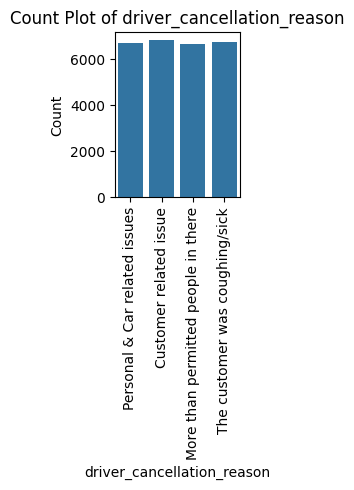

In [80]:
vis_cat_cols(data,['driver_cancellation_reason'], fig_size=(5,5))

In [81]:
driver_cancel_summary=data[data['booking_status']=='Cancelled by Driver'].groupby('driver_cancellation_reason').agg(total_cancelled=('booking_id','count'))
driver_cancel_summary['cancel_percent']=100*driver_cancel_summary['total_cancelled']/driver_cancel_summary['total_cancelled'].sum()
driver_cancel_summary.sort_values(by='cancel_percent', ascending=False)

,total_cancelled,cancel_percent
driver_cancellation_reason,,
Customer related issue,6837,25.322222
The customer was coughing/sick,6751,25.003704
Personal & Car related issues,6726,24.911111
More than permitted people in there,6686,24.762963


### **Ans.** *This analysis is primarily descriptive. On analysis of driver cancellations frequency distributions, since these are only populated for driver-cancelled rides. The most frequent reasons cluster around themes-- 'customer related issues', 'customer coughing or sick', 'personal & car related issues', 'more then permitted people in ride'.*
### *The reasons equally drive cancellations, highlighting systemic issues in customer's and driver's behavioral issues laced with safety concerns and pickup coordination.*
### *These concerns directly inform requirement of driver training during onboarding, and setting clearer expectations around car health, clarify wait-time policies, communication with customer, and acceptable cancellations.*
### *At the same time, this analysis highlights customer-driven friction points, indicating a clearer customer-side expectation setting through in-app nudges, pickup readiness reminders, and education around driver safety considerations.*
### *Addressing both these can help reduce driver-cancellations rather than treating them as separate incidents.*

### **Q6. Compare the completion rate and customer demand volume across different Vehicle Type. Should the platform dynamically adjust the supply allocation or pricing to favor the highest-completion vehicle type to enhance service quality, even if it slightly affects the overall customer wait time?**

In [82]:
vehicle_summary=data.groupby('vehicle_type').agg(total_demand=('booking_id','count'), completed=('is_completed','sum'))
vehicle_summary['completion_rate']=100*vehicle_summary['completed']/vehicle_summary['total_demand']
vehicle_summary['weighted_completion_rate']=np.log1p(vehicle_summary['total_demand'])*vehicle_summary['completion_rate']/100

In [83]:
vehicle_summary.sort_values(by='completion_rate', ascending=False)

,total_demand,completed,completion_rate,weighted_completion_rate
vehicle_type,,,,
Uber XL,4449,2783,62.553383,5.254897
Bike,22517,14034,62.326242,6.246380
Go Mini,29806,18549,62.232436,6.411496
Premier Sedan,18111,11252,62.127989,6.091233
eBike,10557,6551,62.053614,5.749043
Auto,37419,23155,61.880328,6.515974
Go Sedan,27141,16676,61.442099,6.272524


In [84]:
vehicle_summary.sort_values(by='weighted_completion_rate', ascending=False)

,total_demand,completed,completion_rate,weighted_completion_rate
vehicle_type,,,,
Auto,37419,23155,61.880328,6.515974
Go Mini,29806,18549,62.232436,6.411496
Go Sedan,27141,16676,61.442099,6.272524
Bike,22517,14034,62.326242,6.246380
Premier Sedan,18111,11252,62.127989,6.091233
eBike,10557,6551,62.053614,5.749043
Uber XL,4449,2783,62.553383,5.254897


### **Ans.** *While there are small differences in completion rate across vehicle type, they are tightly clustered around ~62%, indicating that the vehicle type alone is not a strong indicator of completion. Higher weighted scores for Auto primarily reflect its dominant market share, not superior reliability. Therefore, globally favoring one vehicle over the other would not materially improve service quality and can hurt.*
### *Instead, supply allocation and pricing should be driven by contextual factors like zone-level risk, driver reliability, time based demand. Vehicle_type becomes a secondary constraint than a primary lever. For example, bikes during peak congestions in morning rush.*

# Data Modelling

In [85]:
dataset.isna().sum()

,0
booking_status_bin,0
vehicle_type,0
pickup_location,0
drop_location,0
avg_vtat,0
avg_ctat,0
time_hour,0
time_slot_of_day,0
day_type,0
pickup_location_density_score,0


#### Dataset is without nulls now

In [86]:
cat_cols, num_cols =find_cat_num_cols(dataset)
cat_cols, num_cols

(['booking_status_bin', 'vehicle_type', 'time_slot_of_day', 'day_type'],
 ['pickup_location',
  'drop_location',
  'avg_vtat',
  'avg_ctat',
  'time_hour',
  'pickup_location_density_score',
  'drop_location_density_score'])

# Code for Modelling

In [87]:
def remove_outliers(df, num_cols):
  z_scores=stats.zscore(df[num_cols])
  outliers=np.abs(z_scores)>1.5
  filtered_rows=np.any(outliers,axis=1)
  cleaned_data=df[~filtered_rows].reset_index(drop=True)
  return cleaned_data

In [88]:
def scale_data(cleaned_data, num_columns, cat_columns):
  num_data=cleaned_data[num_columns]
  cat_data=cleaned_data[cat_columns]
  scaler=StandardScaler()
  scaled_num_data=pd.DataFrame(scaler.fit_transform(num_data),columns=num_columns)
  scaled_data = pd.concat([scaled_num_data,cat_data],axis=1)
  return scaled_data

# clean_data=remove_outliers(data,num_cols)
# scaled_data = scale_data(clean_data,num_cols,cat_cols)
# scaled_data

In [145]:
def run_model_without_smote(df, model, name):
  x=df.drop('booking_status_bin', axis=1)
  y=df['booking_status_bin'].astype(int) # Explicitly cast y to int here
  x_train, x_test, y_train, y_test = train_test_split(x,y,stratify=y, test_size=0.2, random_state=42)

  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)

  return y_pred,y_test, x_test.index, model, x_test, y_test

In [146]:
from sklearn.metrics import f1_score
def models_no_smote(df, fairness_df):
    results = []  # Initialize a list to store results
    cm_data = []  # Initialize a list to store confusion matrix data
    roc_data = []  # Initialize a list to store ROC curve data
    fairness_data = []
    models = {
        "Logistic Regression": LogisticRegression(
            C=0.1,
            class_weight='balanced',
            max_iter=1000
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.05
        ),

        "Gaussian Naive Bayes": GaussianNB(),

        "K-Nearest Neighbors": KNeighborsClassifier(
            n_neighbors=15,
            weights='distance'
        ),

        "Decision Tree": DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=100,
            class_weight='balanced'
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=100,
            class_weight='balanced',
            random_state=42
        )
    }

    # Iterate through the models
    for name, model in models.items():
        # Run the model and get predictions and actual labels
        predictions, y_test, test_idx, model_after_fit, x_val, y_val = run_model_without_smote(df, model, name)

        # Evaluate the model and calculate metrics
        accuracy, precision, recall, f1, cm = evaluate_model(y_test, predictions)

        # Calculate ROC curve data
        fpr, tpr, _ = roc_curve(y_test, predictions)
        roc_auc = auc(fpr, tpr)

        # Store the results in a dictionary
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Model after fit": model_after_fit,
            "X Val":x_val,
            "Y Val":y_val
        })
        test_df = fairness_df.loc[test_idx].copy()
        print(test_df.columns)
        test_df['y_true'] = y_test.values
        test_df['y_pred'] = predictions

        for bucket, bucket_df in test_df.groupby('pickup_zone'):
            if len(bucket_df) < 50:  # stability guard
                continue
            bucket_f1 = f1_score(bucket_df['y_true'], bucket_df['y_pred'])

            fairness_data.append({
                "Model": name,
                "pickup_zone": bucket,
                "F1 Score": round(bucket_f1, 4),
                "Support": len(bucket_df)
            })

        cm_data.append({
            "Model": name,
            "Matrix": cm
        })

        # Store ROC curve data in a dictionary
        roc_data.append({
            "Model": name,
            "FPR": fpr.tolist(),
            "TPR": tpr.tolist(),
            "AUC": roc_auc
        })

    # Create a DataFrame from the results, round the values, and sort by accuracy
    results_df = pd.DataFrame(results).round(4).sort_values(by="Accuracy", ascending=False)
    fairness_df = pd.DataFrame(fairness_data).round(4).sort_values(by="F1 Score", ascending=False)

    return results_df, cm_data, roc_data, fairness_df

In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred):
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate precision
    precision = precision_score(y_true, y_pred)

    # Calculate recall
    recall = recall_score(y_true, y_pred)

    # Calculate F1 score
    f1 = f1_score(y_true, y_pred)

    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, cm

In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def pipeline_no_smote(df):
    fairness_cols = ['pickup_zone']
    fairness_df = df[fairness_cols].copy()

    y = df['booking_status_bin'].copy()
    X = df.drop(columns=['booking_status_bin'] + fairness_cols, axis=1).copy()

    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # numerical_features_for_processing = X.columns.tolist()

    combined_data_for_outliers = pd.concat([X, y.rename('booking_status_bin')], axis=1)

    cleaned_combined_data = remove_outliers(combined_data_for_outliers, numerical_cols)

    y_processed = cleaned_combined_data['booking_status_bin'].reset_index(drop=True)
    X_processed = cleaned_combined_data.drop('booking_status_bin', axis=1).reset_index(drop=True)

    fairness_processed = fairness_df.loc[X_processed.index].reset_index(drop=True)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ],
        remainder='drop'
    )

    X_transformed = preprocessor.fit_transform(X_processed)

    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    final_feature_names = numerical_cols + list(ohe_feature_names)

    X_final = pd.DataFrame(
        X_transformed,
        columns=final_feature_names
    )

    final_df = pd.concat([X_final, y_processed], axis=1)

    performance, cm_data, roc_data, fairness = models_no_smote(final_df, fairness_processed)
    return performance, cm_data, roc_data, fairness
    # # Since all features in `X_processed` are intended for scaling, `cat_cols` will be an empty list.
    # scaled_X = scale_data(X_processed, numerical_cols, [])

    # # It's crucial that `y_processed` has its index reset to align correctly with `scaled_X`.
    # final_data_for_models = pd.concat([scaled_X, y_processed.reset_index(drop=True)], axis=1)

    # performance, cm_data, roc_data = models_no_smote(final_data_for_models)

    # return performance, cm_data, roc_data

In [93]:
def plot_confusion_matrix(cm, labels, model_name, ax):
    # Create an image of the confusion matrix
    im = ax.imshow(cm, interpolation='nearest')

    # Add a colorbar to the plot
    ax.figure.colorbar(im, ax=ax)

    # Set axis labels and title
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels,
           title=f'Confusion Matrix for {model_name}',
           ylabel='True label',
           xlabel='Predicted label')

    # Add text annotations for each cell in the matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="w")

In [94]:
def plot_confusion_matrices(cm_data, columns, rows):
    # Determine the number of models and create subplots accordingly
    num_models = len(cm_data)

    # Calculate the actual number of rows needed based on num_models and desired columns
    actual_rows = (num_models + columns - 1) // columns

    fig, axes = plt.subplots(actual_rows, columns, figsize=(15, 10))

    # Flatten the axes array to easily iterate through each subplot
    # This handles cases where actual_rows or columns might be 1, resulting in a 1D axes array
    axes = axes.flatten()

    # Iterate through the confusion matrix data for each model
    for i, entry in enumerate(cm_data):
        model_name = entry['Model']
        cm = entry['Matrix']
        class_labels = ['Incomplete', 'Completed']

        plot_confusion_matrix(cm, class_labels, model_name, axes[i])

    # Turn off any empty subplots if the grid has more slots than models
    for i in range(num_models, actual_rows * columns):
        axes[i].axis('off')

    # Adjust the layout and display the subplots
    plt.tight_layout()
    plt.show()

In [114]:
zone_labels=['low', 'medium','high']
p33=dataset['pickup_location_density_score'].quantile(0.33)
p66=dataset['pickup_location_density_score'].quantile(0.66)
dataset['pickup_zone']=pd.cut(dataset['pickup_location_density_score'],bins=[0,p33,p66,np.inf],labels=zone_labels,right=False)
dataset['pickup_zone'].value_counts()

,count
pickup_zone,
high,51657
medium,49410
low,48933


In [116]:
dataset.drop(columns=['avg_vtat','avg_ctat'], axis=1, inplace=True, errors='ignore')
dataset.columns

Index(['booking_status_bin', 'vehicle_type', 'pickup_location',
       'drop_location', 'time_hour', 'time_slot_of_day', 'day_type',
       'pickup_location_density_score', 'drop_location_density_score',
       'pickup_zone'],
      dtype='object')

In [178]:
import time
start_time = time.perf_counter()
# pipeline_no_smote returns (performance_df, cm_data, roc_data, fairness_df)
full_model_results, cm_data_no_smote, roc_data_no_smote, fairness = pipeline_no_smote(dataset)
end_time = time.perf_counter()
time_taken_no_smote=np.round(end_time - start_time,2)

# Store the full results for SHAP analysis
models_after_fit = full_model_results.copy()

# Prepare the performance dataframe for display by dropping internal columns
performance_no_smote = full_model_results.drop(columns=['Model after fit', 'X Val', 'Y Val'], axis=1, errors='ignore')

Index(['pickup_zone'], dtype='object')


/tmp/ipython-input-3963442004.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, bucket_df in test_df.groupby('pickup_zone'):


Index(['pickup_zone'], dtype='object')


/tmp/ipython-input-3963442004.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, bucket_df in test_df.groupby('pickup_zone'):


Index(['pickup_zone'], dtype='object')


...

/tmp/ipython-input-3963442004.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, bucket_df in test_df.groupby('pickup_zone'):


Index(['pickup_zone'], dtype='object')


/tmp/ipython-input-3963442004.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, bucket_df in test_df.groupby('pickup_zone'):


Index(['pickup_zone'], dtype='object')


/tmp/ipython-input-3963442004.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, bucket_df in test_df.groupby('pickup_zone'):


In [179]:
print(f"Time taken to run models: {time_taken_no_smote} secs")

# 'performance_no_smote' is now prepared for display in the previous cell.
performance_no_smote.sort_values(by='F1 Score',ascending=False).round(2)

Time taken to run models: 254.0 secs


,Model,Accuracy,Precision,Recall,F1 Score
2,AdaBoost,0.62,0.62,1.00,0.77
1,Gradient Boosting,0.62,0.62,1.00,0.77
4,K-Nearest Neighbors,0.58,0.62,0.82,0.71
5,Decision Tree,0.54,0.63,0.64,0.63
6,Random Forest,0.51,0.63,0.53,0.58
3,Gaussian Naive Bayes,0.50,0.61,0.52,0.56
0,Logistic Regression,0.49,0.61,0.50,0.55


In [128]:
fairness.sort_values(by='F1 Score',ascending=False).round(4)

,Model,pickup_zone,F1 Score,Support
7,AdaBoost,medium,0.7716,8024
4,Gradient Boosting,medium,0.7710,8024
6,AdaBoost,low,0.7699,7893
3,Gradient Boosting,low,0.7695,7893
8,AdaBoost,high,0.7624,8427
5,Gradient Boosting,high,0.7616,8427
12,K-Nearest Neighbors,low,0.7133,7893
13,K-Nearest Neighbors,medium,0.7101,8024
14,K-Nearest Neighbors,high,0.6994,8427
16,Decision Tree,medium,0.6357,8024


### **Q7. Evaluate the model's prediction fairness by comparing its F1 -score across different major pickup zones (e.g., North vs. South NCR). If performance disparities are found, what mitigation strategy (e.g., collecting more data from minority zones, using balanced loss) must be implemented to prevent service inequality?**

### **Ans.** *To evaluate fairness, I compared F1 scores across pickup locations segmented into low, medium, high based on pickup_location_density_score that is based on historical demand. The results show highly consistent performance across all density groups for every model, with minor variations. Medium density zone exhibit slightly higher F1 scores, while high-density zones exhibit marginally lower, likely due to complex and competitive supply-demand dynamics rather than model bias. Since no group is systematically disadvantaged, no fairness related mitigation such as reweighting or oversapling is required. Improvements should instead focus on enriching real-time operational features, particulrly in high-density zones.*

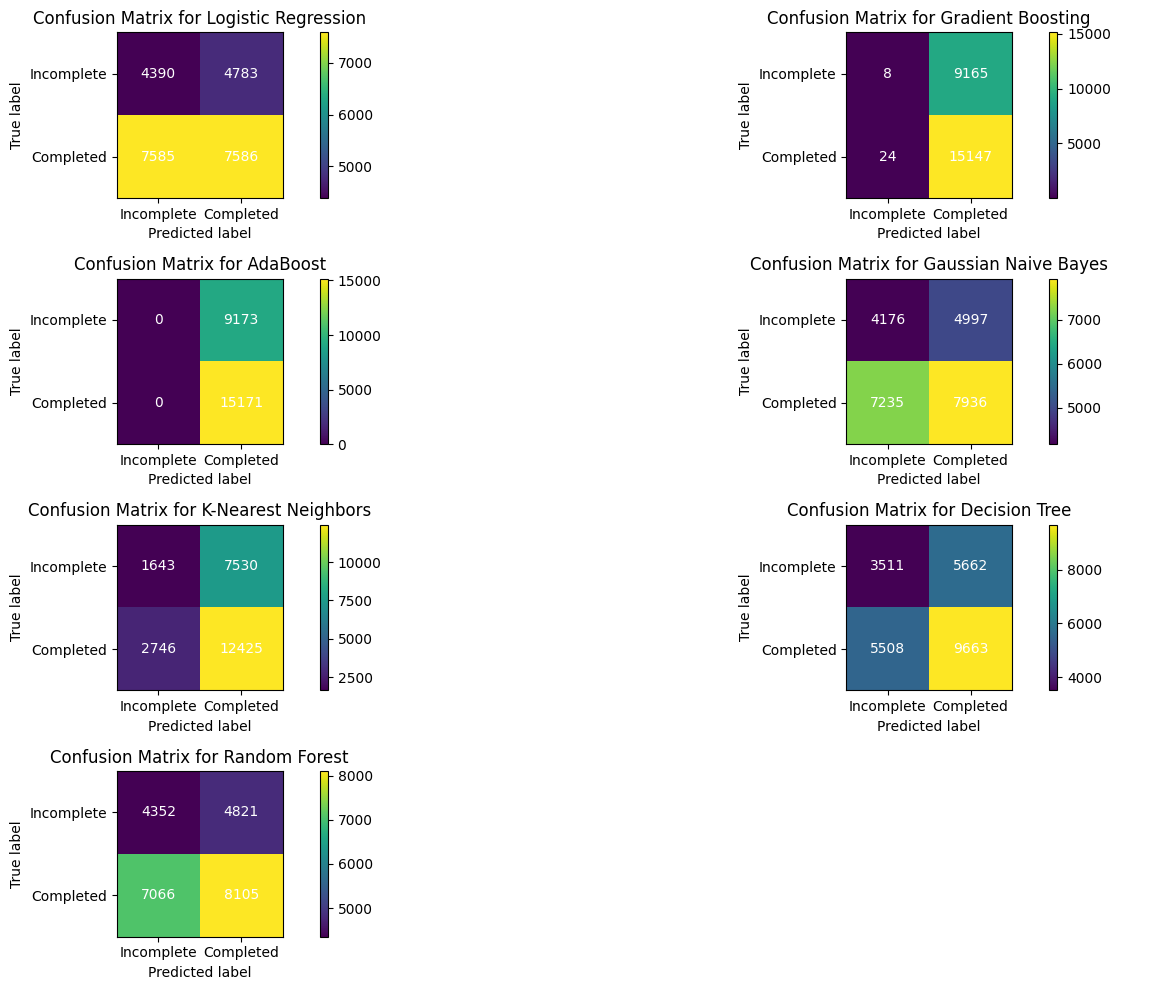

In [127]:
plot_confusion_matrices(cm_data_no_smote,columns=2,rows=3)

### The confusion matrices indicate that models either collapse into predicting majority class (AdaBoost, GradientBoost) or behave close to random, missing a large fraction of incomplete rides (Random Forest, Decision Tree, Logistic Regression, Gaussian Naive) or slightly miss failures but still weak (KNN). This confirms that after removing leakage columns, request-time features lack sufficient discriminatory power. Even ensemble models cannot meaningfully separate failures from successful rides, indicating that successfull completion is driven by real-time supply-demand dynamics than static booking attributes.

In [99]:
def plot_roc_curve(roc_data):
    plt.figure(figsize=(8, 6))
    plt.title('Receiver Operating Characteristic (ROC) Curve')

    for model_data in roc_data:
        model_name = model_data['Model']
        fpr = model_data['FPR']
        tpr = model_data['TPR']
        auc = model_data['AUC']

        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

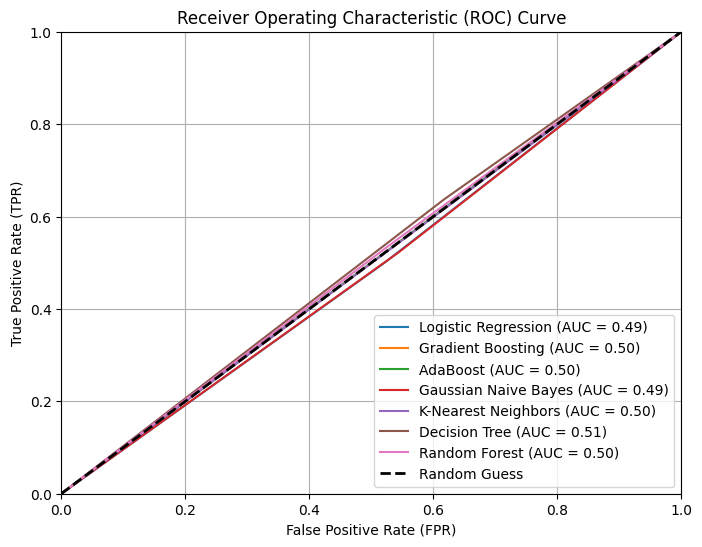

In [100]:
plot_roc_curve(roc_data_no_smote)

### After removing post-outcome leakage columns, and tuning conservatively, all models converge to near baseline performance (auc=0.5). Boosting models achieve high f1_scrore by predicting majority class, which is operationally not useful. This implies that ride completion is driven by real-time supply dynamics not present in the dataset, making this suitable for rule-based or decision-support systems rather than pure-prediction.

### Q3. **Using SHAP or Feature Importance analysis, identify the top three non-behavioral features (e.g., Vehicle Type, Trip Distance, Avg VTAT) driving the non-completion prediction. Which operational levers (e.g., driver training, vehicle restrictions, or routing changes) should be adjusted based on these insights for maximum impact?**

In [150]:
models_after_fit

,Model,Accuracy,Precision,Recall,F1 Score,Model after fit
2,AdaBoost,0.6232,0.6232,1.0000,0.7679,"(DecisionTreeClassifier(max_depth=1, random_st..."
1,Gradient Boosting,0.6225,0.6230,0.9984,0.7673,([DecisionTreeRegressor(criterion='friedman_ms...
4,K-Nearest Neighbors,0.5779,0.6227,0.8190,0.7075,"KNeighborsClassifier(n_neighbors=15, weights='..."
5,Decision Tree,0.5412,0.6305,0.6369,0.6337,DecisionTreeClassifier(class_weight='balanced'...
6,Random Forest,0.5117,0.6270,0.5342,0.5769,"(DecisionTreeClassifier(max_depth=6, max_featu..."
3,Gaussian Naive Bayes,0.4975,0.6136,0.5231,0.5648,GaussianNB()
0,Logistic Regression,0.4919,0.6133,0.5000,0.5509,"LogisticRegression(C=0.1, class_weight='balanc..."


### Though KNN showed slightly better balance in classification, it lacks interpretability for SHAP(values are unstable, conceptually weak). Therefore, Decision tree is used for SHAP analysis to extract stable and feature dependence explanations.

In [182]:
DT_model=models_after_fit[models_after_fit['Model']=='Decision Tree']['Model after fit'].iloc[0]

In [ ]:
dt_row_index = performance_no_smote[performance_no_smote['Model'] == 'Decision Tree'].index[0]

x_val_dt_model = models_after_fit.loc[dt_row_index, 'X Val']
y_val_dt_model = models_after_fit.loc[dt_row_index, 'Y Val']

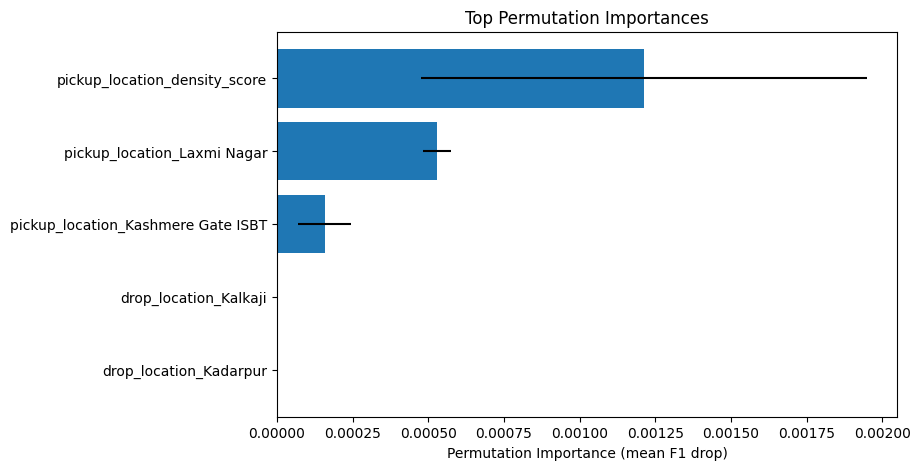

In [189]:
# permutation importance = if I destroy this feature how it is going to effect F1 score

from sklearn.inspection import permutation_importance

# Use x_val_dt_model and y_val_dt_model for permutation importance
perm = permutation_importance(
    DT_model,
    x_val_dt_model,
    y_val_dt_model,
    scoring='f1',
    n_repeats=5,
    random_state=42
)
imp = pd.DataFrame({
    "feature": x_val_dt_model.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp["feature"][:5], imp["importance_mean"][:5], xerr=imp["importance_std"][:5])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (mean F1 drop)")
plt.title("Top Permutation Importances")
plt.show()

### The marginal F1-score reductions observed for pickup_location_density_score and certain pickup locations (e.g., Laxmi Nagar, Kashmere Gate ISBT) are statistically insignificant (~0.00125), suggesting minimal sensitivity to their exclusion. Therefore, SHAP values were used as the primary basis for feature importance interpretation

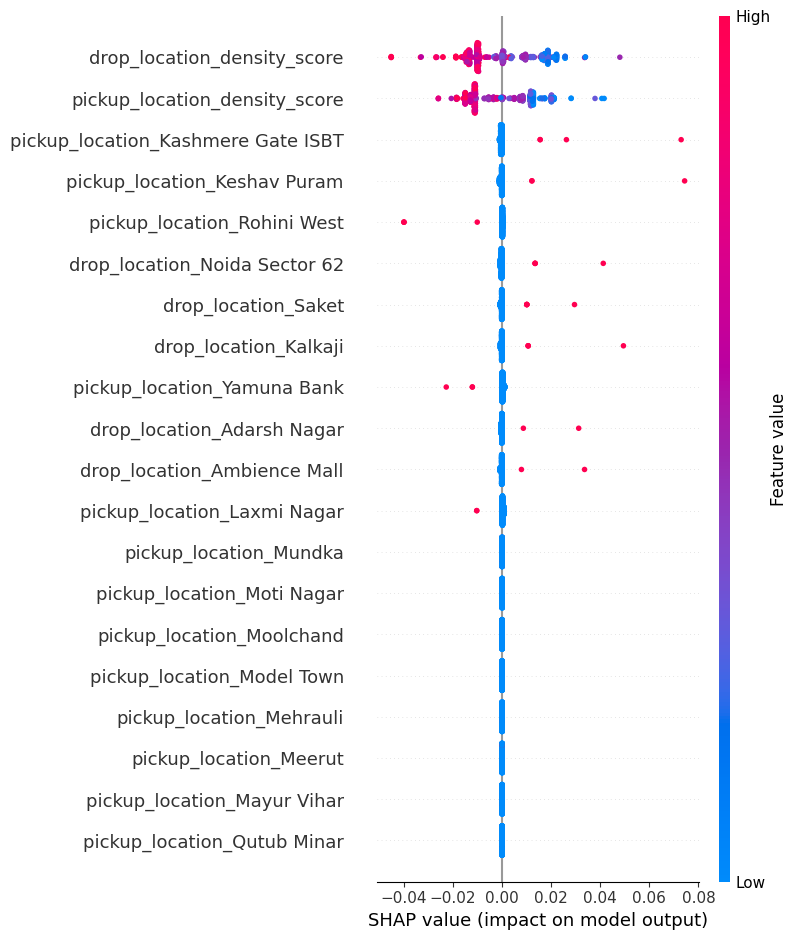

In [187]:
#SHAP for feature importance
import shap

X_sample = x_val_dt_model.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(DT_model)
shap_values = explainer.shap_values(X_sample)

# For a binary classification model where shap_values is a 3D array (n_samples, n_features, n_classes),
shap_values_for_class_0 = shap_values[:, :, 0]

# Ensure consistency before plotting
assert DT_model.n_features_in_ == X_sample.shape[1], "Model and X_sample feature count mismatch!"
assert shap_values_for_class_0.shape == (X_sample.shape[0], X_sample.shape[1]), "Shape of extracted SHAP values for class 1 is incorrect!"

shap.summary_plot(shap_values_for_class_0, X_sample)

### **Ans.** *SHAP Analysis on interpretable Decision Tree model shows us that non-completion risk is primarily influenced by loaction based and non-behavioral features.*
### *Only small set of features influence non-completion.*
### **Top drivers of non-completion(Non-behavioral):**
### 1. *drop_location_density_score: Higher density tend to have lower probability of non-completion, can be due to driver availability or infrastructure availability or more driver familiarity. Similarly, low density scores have higher chaces of non-completion due to poor navigation or peripheral location or uncertainity of return demand or safety concerns of driver.*
### 2. *pickup_location_density_score: Similarly, high reluctance to acceptance for low density score zones--poor navigation metrics, poor communication with customer, safety concerns, etc. High acceptance to high density zone due to driver awareness on location, proximity to commercial hubs, better road access, etc.*
### 3. *Other features(mostly ohe pickup locations) have dots mostly centered around 0 with ocassional red dots on positive side of SHAP indicating these locations--like Kashmere_Gate_ISBT, Keshav_Puram-- have likely chances of non-completion when they are pickup locations.*
### *Therefore, maximum impact will come from operational levers like driver positioning, zone specific incentives, and improving routing support in less dense drop locations rather than model-based decisioning.*